In [1]:
# Adaptive Ensemble-Guided Hybrid Quantum-Classical Framework

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from qiskit import __version__
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_aer import Aer

RANDOM_STATE = 42
ALPHA = 0.6
BETA = 0.4
THRESHOLD_VALUES = np.arange(0.10, 0.71, 0.10)

print(f"Qiskit version: {__version__}")

Matplotlib is building the font cache; this may take a moment.
C:\Users\jyash\AppData\Local\Temp\ipykernel_28152\1847981333.py:22: DeprecationWarning: ``qiskit.algorithms`` has been migrated to an independent package: https://github.com/qiskit-community/qiskit-algorithms. The ``qiskit.algorithms`` import path is deprecated as of qiskit-terra 0.25.0 and will be removed no earlier than 3 months after the release date. Please run ``pip install qiskit_algorithms`` and use ``import qiskit_algorithms`` instead.
  from qiskit.algorithms.optimizers import COBYLA


Qiskit version: 0.45.0


In [2]:
backend = Aer.get_backend("aer_simulator")
print("Using backend:", backend.name)

Using backend: aer_simulator


In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

RANDOM_STATE = 42

# =========================
# 1. Load inbuilt dataset
# =========================
breast = load_breast_cancer()

X = breast.data
y = breast.target

breast_df = pd.DataFrame(X, columns=breast.feature_names)
breast_df["diagnosis"] = y

print("Original Dataset Shape:", breast_df.shape)

# =========================
# 2. Train-test split
# =========================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# =========================
# 3. Standard Scaling
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# =========================
# 4. PCA: 30 -> 4
# =========================
pca = PCA(n_components=4, random_state=RANDOM_STATE)
X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_,4))
print("Total retained variance:", np.sum(pca.explained_variance_ratio_))

Original Dataset Shape: (569, 31)
X_train shape: (455, 4)
X_test shape: (114, 4)
Explained variance ratio: [0.4441 0.1894 0.0954 0.0672]
Total retained variance: 0.796261558075481


In [6]:
# 2) Classical ensemble training
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
lr_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
gb_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

rf_conf = rf_model.predict_proba(X_test).max(axis=1)
lr_conf = lr_model.predict_proba(X_test).max(axis=1)
gb_conf = gb_model.predict_proba(X_test).max(axis=1)

rf_acc = accuracy_score(y_test, rf_pred)
print(f"Random Forest accuracy: {rf_acc:.4f}")

Random Forest accuracy: 0.9298


In [7]:
# 3) Ensemble consensus prediction + ambiguity score engine

def majority_vote(pred_a, pred_b, pred_c):
    stacked = np.vstack([pred_a, pred_b, pred_c])
    # For binary classification, majority vote is equivalent to >=2 positives.
    return (stacked.sum(axis=0) >= 2).astype(int)

ensemble_pred = majority_vote(rf_pred, lr_pred, gb_pred)
ensemble_acc = accuracy_score(y_test, ensemble_pred)

average_confidence = np.mean(np.vstack([rf_conf, lr_conf, gb_conf]), axis=0)
confidence_variance = np.var(np.vstack([rf_conf, lr_conf, gb_conf]), axis=0)
ambiguity_score_test = ALPHA * (1 - average_confidence) + BETA * confidence_variance

print(f"Classical ensemble accuracy (majority vote): {ensemble_acc:.4f}")
print("Ambiguity score summary:")
print(pd.Series(ambiguity_score_test).describe())

Classical ensemble accuracy (majority vote): 0.9474
Ambiguity score summary:
count    114.000000
mean       0.034897
std        0.062675
min        0.000176
25%        0.001622
50%        0.006162
75%        0.023731
max        0.273312
dtype: float64


In [8]:
# 4) Adaptive threshold sweep with VQC routing
# Compute ambiguity scores for TRAIN split as routing source for VQC training.
rf_pred_train = rf_model.predict(X_train)
lr_pred_train = lr_model.predict(X_train)
gb_pred_train = gb_model.predict(X_train)

rf_conf_train = rf_model.predict_proba(X_train).max(axis=1)
lr_conf_train = lr_model.predict_proba(X_train).max(axis=1)
gb_conf_train = gb_model.predict_proba(X_train).max(axis=1)

avg_conf_train = np.mean(np.vstack([rf_conf_train, lr_conf_train, gb_conf_train]), axis=0)
var_conf_train = np.var(np.vstack([rf_conf_train, lr_conf_train, gb_conf_train]), axis=0)
ambiguity_score_train = ALPHA * (1 - avg_conf_train) + BETA * var_conf_train

results = []
best_hybrid_pred = None
best_threshold = None
best_hybrid_acc = -1

for threshold in THRESHOLD_VALUES:
    amb_train_idx = np.where(ambiguity_score_train > threshold)[0]
    amb_test_idx = np.where(ambiguity_score_test > threshold)[0]

    hybrid_pred = ensemble_pred.copy()

    # Train VQC only when ambiguous train/test subsets are viable.
    if len(amb_train_idx) > 1 and len(np.unique(y_train[amb_train_idx])) > 1 and len(amb_test_idx) > 0:
        feature_map = ZZFeatureMap(feature_dimension=4, reps=1)
        ansatz = RealAmplitudes(num_qubits=4, reps=1)
        optimizer = COBYLA(maxiter=100)

        vqc = VQC(
            feature_map=feature_map,
            ansatz=ansatz,
            loss="cross_entropy",
            optimizer=optimizer,
            quantum_instance=backend,
        )

        vqc.fit(X_train[amb_train_idx], y_train[amb_train_idx])
        hybrid_pred[amb_test_idx] = vqc.predict(X_test[amb_test_idx])

    # Metrics for this threshold
    hybrid_acc = accuracy_score(y_test, hybrid_pred)
    precision = precision_score(y_test, hybrid_pred, zero_division=0)
    recall = recall_score(y_test, hybrid_pred, zero_division=0)
    f1 = f1_score(y_test, hybrid_pred, zero_division=0)
    malignant_recall = recall_score(y_test, hybrid_pred, pos_label=1, zero_division=0)

    results.append(
        {
            "threshold": round(float(threshold), 2),
            "hybrid_accuracy": hybrid_acc,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "malignant_recall": malignant_recall,
            "quantum_samples_used": int(len(amb_test_idx)),
        }
    )

    if hybrid_acc > best_hybrid_acc:
        best_hybrid_acc = hybrid_acc
        best_threshold = float(threshold)
        best_hybrid_pred = hybrid_pred.copy()

results_df = pd.DataFrame(results)
results_df

C:\Users\jyash\AppData\Local\Temp\ipykernel_28152\4068384243.py:32: DeprecationWarning: The quantum_instance argument is deprecated as of version 0.5.0 and will be removed no sooner than 3 months after the release. Instead use the sampler argument.
  vqc = VQC(
c:\Users\jyash\Quantum_Breast_cancer_diagnosis\.venv\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


,threshold,hybrid_accuracy,precision,recall,f1,malignant_recall,quantum_samples_used
0,0.1,0.912281,0.930556,0.930556,0.930556,0.930556,16
1,0.2,0.947368,0.945946,0.972222,0.958904,0.972222,4
2,0.3,0.947368,0.945946,0.972222,0.958904,0.972222,0
3,0.4,0.947368,0.945946,0.972222,0.958904,0.972222,0
4,0.5,0.947368,0.945946,0.972222,0.958904,0.972222,0
5,0.6,0.947368,0.945946,0.972222,0.958904,0.972222,0
6,0.7,0.947368,0.945946,0.972222,0.958904,0.972222,0


In [9]:
# 5) Final results table and best-threshold selection
best_row = results_df.loc[results_df["hybrid_accuracy"].idxmax()].copy()

print("Best threshold by hybrid accuracy:", best_row["threshold"])
print("Best hybrid accuracy:", round(best_row["hybrid_accuracy"], 4))
print("\nAdaptive threshold experiment results:")
display(results_df)

Best threshold by hybrid accuracy: 0.2
Best hybrid accuracy: 0.9474

Adaptive threshold experiment results:


,threshold,hybrid_accuracy,precision,recall,f1,malignant_recall,quantum_samples_used
0,0.1,0.912281,0.930556,0.930556,0.930556,0.930556,16
1,0.2,0.947368,0.945946,0.972222,0.958904,0.972222,4
2,0.3,0.947368,0.945946,0.972222,0.958904,0.972222,0
3,0.4,0.947368,0.945946,0.972222,0.958904,0.972222,0
4,0.5,0.947368,0.945946,0.972222,0.958904,0.972222,0
5,0.6,0.947368,0.945946,0.972222,0.958904,0.972222,0
6,0.7,0.947368,0.945946,0.972222,0.958904,0.972222,0


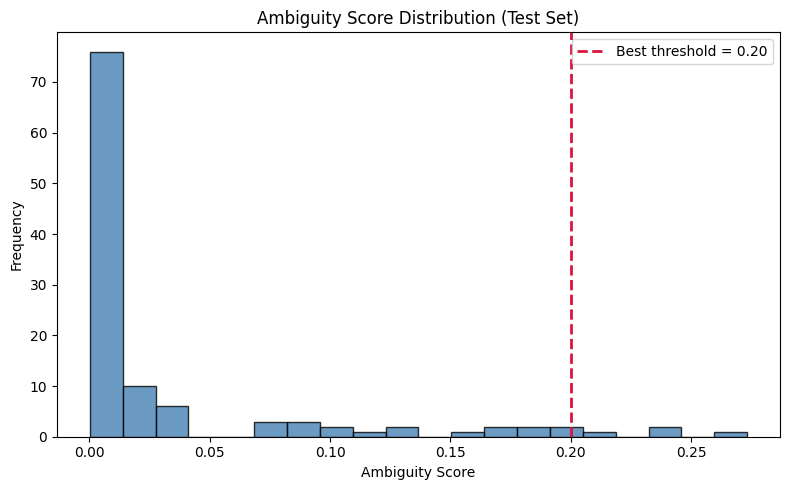

In [10]:
# A) Ambiguity score distribution histogram
plt.figure(figsize=(8, 5))
plt.hist(ambiguity_score_test, bins=20, color="steelblue", alpha=0.8, edgecolor="black")
plt.axvline(best_threshold, color="crimson", linestyle="--", linewidth=2, label=f"Best threshold = {best_threshold:.2f}")
plt.title("Ambiguity Score Distribution (Test Set)")
plt.xlabel("Ambiguity Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

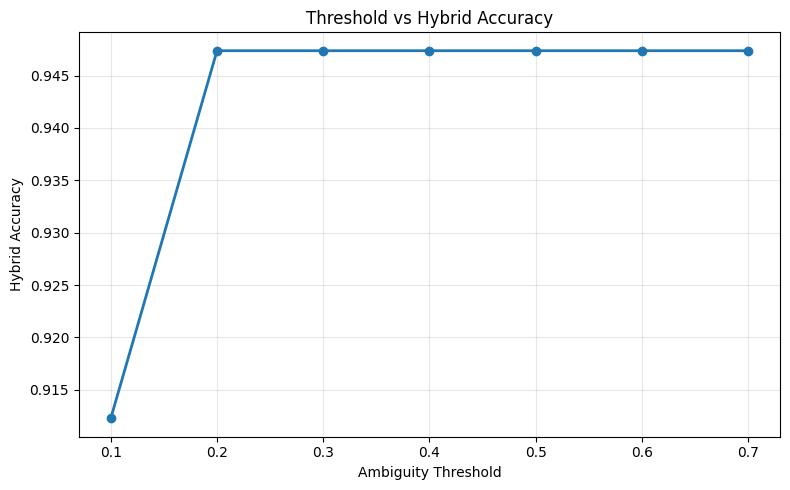

In [11]:
# B) Threshold vs Hybrid Accuracy
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["hybrid_accuracy"], marker="o", linewidth=2)
plt.title("Threshold vs Hybrid Accuracy")
plt.xlabel("Ambiguity Threshold")
plt.ylabel("Hybrid Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

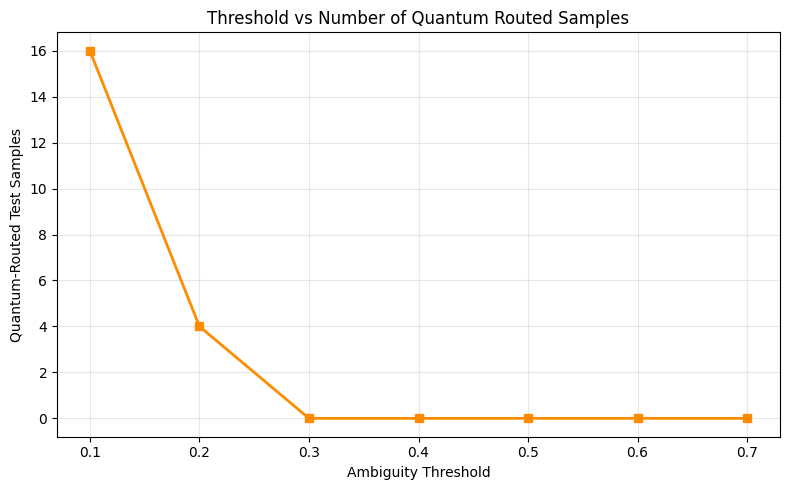

In [12]:
# C) Threshold vs Number of Quantum Routed Samples
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["quantum_samples_used"], marker="s", color="darkorange", linewidth=2)
plt.title("Threshold vs Number of Quantum Routed Samples")
plt.xlabel("Ambiguity Threshold")
plt.ylabel("Quantum-Routed Test Samples")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

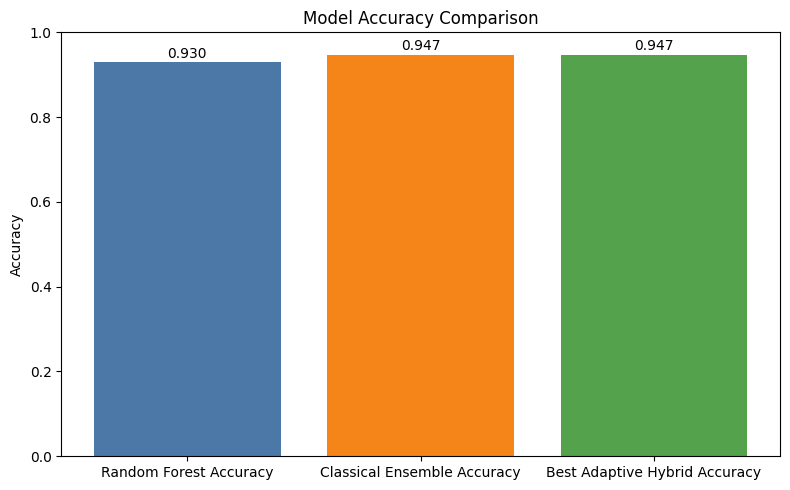

In [13]:
# D) Comparison bar chart (RF vs Ensemble vs Best Adaptive Hybrid)
comparison_labels = [
    "Random Forest Accuracy",
    "Classical Ensemble Accuracy",
    "Best Adaptive Hybrid Accuracy",
]
comparison_scores = [rf_acc, ensemble_acc, best_hybrid_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_labels, comparison_scores, color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center")

plt.tight_layout()
plt.show()

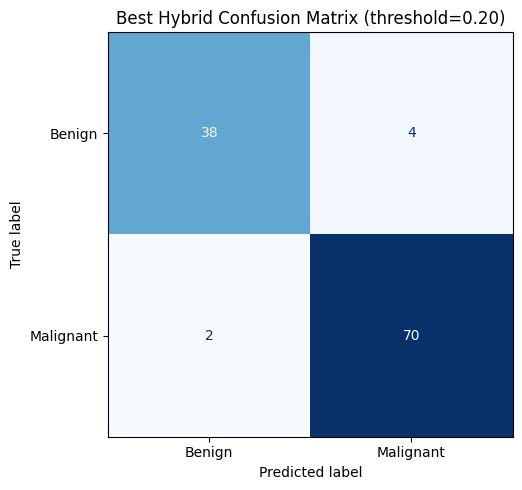

In [14]:
# E) Confusion matrix for best hybrid model
cm_best = confusion_matrix(y_test, best_hybrid_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["Benign", "Malignant"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Best Hybrid Confusion Matrix (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.show()

In [15]:
# Optional: compact performance summary at best threshold
best_metrics = results_df.loc[results_df["threshold"] == round(best_threshold, 2)].iloc[0]
print("Best-threshold metrics:")
print(best_metrics)

Best-threshold metrics:
threshold               0.200000
hybrid_accuracy         0.947368
precision               0.945946
recall                  0.972222
f1                      0.958904
malignant_recall        0.972222
quantum_samples_used    4.000000
Name: 1, dtype: float64


## Adaptive Hybrid Experiment Notes

- Classical stage uses a three-model ensemble (RF, Logistic Regression, Gradient Boosting).
- Ambiguity score is computed as: `0.6*(1-average_confidence) + 0.4*(confidence_variance)`.
- Quantum routing is adaptive across thresholds `0.10` to `0.70`.
- VQC core is preserved with `ZZFeatureMap(4, reps=1)`, `RealAmplitudes(4, reps=1)`, and `COBYLA(maxiter=100)`.


In [16]:
# Per-sample test diagnostics (requested prediction/confidence fields)
test_diagnostics_df = pd.DataFrame(
    {
        "y_true": y_test,
        "rf_pred": rf_pred,
        "rf_conf": rf_conf,
        "lr_pred": lr_pred,
        "lr_conf": lr_conf,
        "gb_pred": gb_pred,
        "gb_conf": gb_conf,
        "average_confidence": average_confidence,
        "confidence_variance": confidence_variance,
        "ambiguity_score": ambiguity_score_test,
    }
)

display(test_diagnostics_df.head(10))


,y_true,rf_pred,rf_conf,lr_pred,lr_conf,gb_pred,gb_conf,average_confidence,confidence_variance,ambiguity_score
0,0,0,1.000,0,1.000000,0,0.999122,0.999707,1.713053e-07,0.000176
1,1,1,1.000,1,0.999963,1,0.997523,0.999162,1.343424e-06,0.000503
2,0,0,0.960,0,0.937984,0,0.981057,0.959680,3.092574e-04,0.024316
3,1,1,0.535,1,0.522985,0,0.576507,0.544831,5.257434e-04,0.273312
4,0,0,0.995,0,1.000000,0,0.998933,0.997978,4.622629e-06,0.001215
5,1,1,0.970,1,0.984749,1,0.992473,0.982407,8.691479e-05,0.010590
6,1,1,0.990,1,0.999986,1,0.998501,0.996162,1.935530e-05,0.002310
7,0,0,0.995,0,0.999994,0,0.998517,0.997837,4.387474e-06,0.001300
8,0,0,0.990,0,0.999512,0,0.997854,0.995789,1.721347e-05,0.002534
9,0,0,0.985,0,1.000000,0,0.997776,0.994259,4.368592e-05,0.003462


## Reproducibility

- `random_state=42` is fixed for train/test split and all classical models.
- PCA transformation is fit on train and applied to test.
- Threshold sweep is deterministic for the same environment and package versions.

## End of Adaptive Ensemble-Guided Hybrid Workflow